# CSC221 Group Project
**Owner** : Jaqueline Pelaez-Velazquez
**collaborator**: Rachel Reyes



# Data Collection
This project uses a REST API to collect data from sustainable seafood information from the NOAA fisheries website using REST API. The data is stored in a pandas DataFrame, displayed in a table and saved as a CSV file for further analysis.


In [2]:
import requests 
import pandas as pd

In [3]:
url = "https://www.fisheries.noaa.gov/topic/sustainable-seafood"
response = requests.get(url)
print("Status Code:", response.status_code)


Status Code: 200


## Creating the DataFrame
extracts information from the webpage, stores it in a pandas DataFrame, displays the firsy 10 rows and saves the data as a CSV file

In [4]:
from bs4 import BeautifulSoup
#get the website
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")
# collect headings from page
headings = []

for heading in soup.find_all(["h2", "h3"]):
    text = heading.get_text(strip=True)
    if text:
        headings.append(text)

df = pd.DataFrame(headings, columns=["NOAA Sustainable Seafood"])

#display first 10 rows
print(df.head(10))
#save file
df.to_csv("CSC221-gp-data.csv", index=False)
print("CSV file saved successfully!")
                  


                            NOAA Sustainable Seafood
0                                Sustainable Seafood
1                                      Featured News
2  Reducing Burdens on Domestic Fishing and Incre...
3             Celebrate National Culinary Arts Month
4  Fire Up the Grill and Celebrate Culinary Arts ...
5  Mid-Atlantic Fishery Management: Science, Stew...
6                                   More Information
7                                    Upcoming Events
8                         Open Funding Opportunities
9                  19.1 pounds of fish and shellfish
CSV file saved successfully!


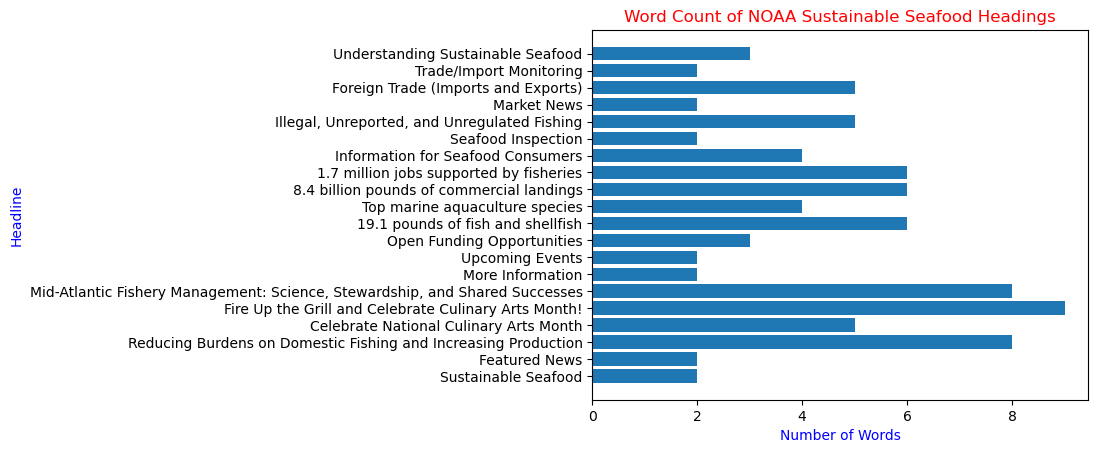

Visualization saved successfully!


In [6]:
import matplotlib.pyplot as plt

df["Word Count"] = df["NOAA Sustainable Seafood"].apply(lambda x: len(x.split()))

twenty_head = df.head(20)

plt.figure()
plt.barh(twenty_head["NOAA Sustainable Seafood"], twenty_head["Word Count"])

plt.title("Word Count of NOAA Sustainable Seafood Headings",color="red")
plt.xlabel("Number of Words", color="blue")
plt.ylabel("Headline", color="blue")
plt.savefig("CSC221-visual.png", bbox_inches="tight")
plt.show()
print("Visualization saved successfully!")